In [0]:
customers_path="/Volumes/ey_databricks/default/capstone/customers.csv"
products_path="/Volumes/ey_databricks/default/capstone/products.csv"
orders_path="/Volumes/ey_databricks/default/capstone/orders.csv"
preferences_path="/Volumes/ey_databricks/default/capstone/customer_preferences.json"

In [0]:
customers_df=spark.read.format(
    "csv"
).option(
    "header",
    "true"
).option(
    "inferSchema",
    "true"
).load(
    customers_path
)

products_df=spark.read.format(
    "csv"
).option(
    "header",
    "true"
).option(
    "inferSchema",
    "true"
).load(
    products_path
)

orders_df=spark.read.format(
    "csv"
).option(
    "header",
    "true"
).option(
    "inferSchema",
    "true"
).load(
    orders_path
)

preferences_df=spark.read.format(
    "json"
).option(
    "multiline",
    "true"
).load(
    preferences_path
)

In [0]:
# #2 Read customers.csv
customers_path="/Volumes/ey_databricks/default/capstone/customers.csv"

customers_df=spark.read.format(
    "csv"
).option(
    "header",
    "true"
).option(
    "inferSchema",
    "true"
).load(
    customers_path
)

display(customers_df)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


In [0]:
# #3 Read products.csv
products_path="/Volumes/ey_databricks/default/capstone/products.csv"

products_df=spark.read.format(
    "csv"
).option(
    "header",
    "true"
).option(
    "inferSchema",
    "true"
).load(
    products_path
)

display(products_df)

product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


In [0]:
# #4 Read orders.csv
orders_path="/Volumes/ey_databricks/default/capstone/orders.csv"

orders_df=spark.read.format(
    "csv"
).option(
    "header",
    "true"
).option(
    "inferSchema",
    "true"
).load(
    orders_path
)

display(orders_df)

order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


In [0]:
# #5 Read customer_preferences.json
preferences_path="/Volumes/ey_databricks/default/capstone/customer_preferences.json"

preferences_df=spark.read.format(
    "json"
).option(
    "multiline",
    "true"
).load(
    preferences_path
)

display(preferences_df)

customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


In [0]:
# #6 Display schema of all datasets
customers_df.printSchema()
products_df.printSchema()
orders_df.printSchema()
preferences_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
# #7 Save raw data as Bronze Delta tables
customers_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "bronze_customers"
)

products_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "bronze_products"
)

orders_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "bronze_orders"
)

preferences_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "bronze_customer_preferences"
)

In [0]:
# Verify Bronze tables
display(
    spark.table(
        "bronze_customers"
    )
)

display(
    spark.table(
        "bronze_products"
    )
)

display(
    spark.table(
        "bronze_orders"
    )
)

display(
    spark.table(
        "bronze_customer_preferences"
    )
)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1003,C103,P103,2026-06-02,3,Pending
O1004,C104,P104,2026-06-02,2,Completed
O1005,C105,P105,2026-06-03,4,Cancelled
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


customer_id,loyalty,preferred_channel
C101,"List(1200, Gold)",Online
C102,"List(700, Silver)",Store
C104,"List(2200, Platinum)",Online
C108,"List(1500, Gold)",Mobile App


In [0]:
# #8 Handle null values if present
from pyspark.sql.functions import col, when, month, to_date

customers_clean_df=customers_df.fillna(
    {
        "city":"Unknown",
        "state":"Unknown",
        "customer_type":"Regular"
    }
)

products_clean_df=products_df.fillna(
    {
        "category":"Unknown",
        "unit_price":0
    }
)

orders_clean_df=orders_df.fillna(
    {
        "quantity":0,
        "status":"Unknown"
    }
)

preferences_clean_df=preferences_df

In [0]:
# #9 Flatten customer_preferences.json
preferences_flat_df=preferences_clean_df.select(
    col(
        "customer_id"
    ),
    col(
        "preferred_channel"
    ),
    col(
        "loyalty.tier"
    ).alias(
        "loyalty_tier"
    ),
    col(
        "loyalty.points"
    ).alias(
        "loyalty_points"
    )
)

display(preferences_flat_df)

customer_id,preferred_channel,loyalty_tier,loyalty_points
C101,Online,Gold,1200
C102,Store,Silver,700
C104,Online,Platinum,2200
C108,Mobile App,Gold,1500


In [0]:
# #10 Join customers with preferences
customers_preferences_df=customers_clean_df.join(
    preferences_flat_df,
    on="customer_id",
    how="left"
)

display(customers_preferences_df)

customer_id,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points
C101,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


In [0]:
# #11 Join orders with customers
orders_customers_df=orders_clean_df.join(
    customers_clean_df,
    on="customer_id",
    how="left"
)

display(orders_customers_df)

customer_id,order_id,product_id,order_date,quantity,status,customer_name,city,state,customer_type
C101,O1001,P101,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium
C102,O1002,P102,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular
C103,O1003,P103,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular
C104,O1004,P104,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium
C105,O1005,P105,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,O1006,P106,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium
C107,O1007,P107,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular
C108,O1008,P108,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium
C101,O1009,P102,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium
C104,O1010,P101,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium


In [0]:
# #12 Join orders with products
orders_products_df=orders_clean_df.join(
    products_clean_df,
    on="product_id",
    how="left"
)

display(orders_products_df)

product_id,order_id,customer_id,order_date,quantity,status,product_name,category,unit_price
P101,O1001,C101,2026-06-01,1,Completed,Laptop,Electronics,65000
P102,O1002,C102,2026-06-01,2,Completed,Mobile,Electronics,25000
P103,O1003,C103,2026-06-02,3,Pending,Chair,Furniture,7000
P104,O1004,C104,2026-06-02,2,Completed,Table,Furniture,12000
P105,O1005,C105,2026-06-03,4,Cancelled,Shoes,Fashion,4500
P106,O1006,C106,2026-06-03,1,Completed,Watch,Fashion,8000
P107,O1007,C107,2026-06-04,1,Completed,TV,Electronics,45000
P108,O1008,C108,2026-06-04,5,Completed,Bag,Fashion,3000
P102,O1009,C101,2026-06-05,1,Completed,Mobile,Electronics,25000
P101,O1010,C104,2026-06-05,1,Completed,Laptop,Electronics,65000


In [0]:
# #13 Create revenue = quantity * unit_price
# #14 Create order_month from order_date
# #15 Create customer_segment
silver_orders_df=orders_clean_df.join(
    customers_clean_df,
    on="customer_id",
    how="left"
).join(
    products_clean_df,
    on="product_id",
    how="left"
).withColumn(
    "revenue",
    col(
        "quantity"
    )*col(
        "unit_price"
    )
).withColumn(
    "order_date",
    to_date(
        col(
            "order_date"
        )
    )
).withColumn(
    "order_month",
    month(
        col(
            "order_date"
        )
    )
).withColumn(
    "customer_segment",
    when(
        col(
            "customer_type"
        )=="Premium",
        "High Value"
    ).when(
        col(
            "customer_type"
        )=="Regular",
        "Standard Value"
    ).otherwise(
        "Unknown"
    )
)

display(silver_orders_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
# #16 Save cleaned data as Silver Delta tables
customers_clean_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "silver_customers"
)

products_clean_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "silver_products"
)

preferences_flat_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "silver_customer_preferences"
)

customers_preferences_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "silver_customers_preferences"
)

silver_orders_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "silver_orders"
)

In [0]:
# Verify Silver tables
display(
    spark.table(
        "silver_customers"
    )
)

display(
    spark.table(
        "silver_products"
    )
)

display(
    spark.table(
        "silver_customer_preferences"
    )
)

display(
    spark.table(
        "silver_customers_preferences"
    )
)

display(
    spark.table(
        "silver_orders"
    )
)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


product_id,product_name,category,unit_price
P101,Laptop,Electronics,65000
P102,Mobile,Electronics,25000
P103,Chair,Furniture,7000
P104,Table,Furniture,12000
P105,Shoes,Fashion,4500
P106,Watch,Fashion,8000
P107,TV,Electronics,45000
P108,Bag,Fashion,3000


customer_id,preferred_channel,loyalty_tier,loyalty_points
C101,Online,Gold,1200
C102,Store,Silver,700
C104,Online,Platinum,2200
C108,Mobile App,Gold,1500


customer_id,customer_name,city,state,customer_type,preferred_channel,loyalty_tier,loyalty_points
C101,Rahul Sharma,Hyderabad,Telangana,Premium,Online,Gold,1200
C102,Priya Reddy,Bangalore,Karnataka,Regular,Store,Silver,700
C103,Amit Kumar,Mumbai,Maharashtra,Regular,null,null,null
C104,Sneha Patel,Delhi,Delhi,Premium,Online,Platinum,2200
C105,Farhan Ali,Chennai,Tamil Nadu,Regular,null,null,null
C106,Neha Singh,Pune,Maharashtra,Premium,null,null,null
C107,Arjun Verma,Hyderabad,Telangana,Regular,null,null,null
C108,Meera Nair,Kochi,Kerala,Premium,Mobile App,Gold,1500


product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
# #17 Create temporary views
silver_orders_df.createOrReplaceTempView(
    "orders_silver"
)

customers_clean_df.createOrReplaceTempView(
    "customers_silver"
)

products_clean_df.createOrReplaceTempView(
    "products_silver"
)

preferences_flat_df.createOrReplaceTempView(
    "preferences_silver"
)

In [0]:
# #18 Write SQL query for total revenue
spark.sql(
    """
    select sum(revenue) as total_revenue
    from orders_silver
    """
).show()

+-------------+
|total_revenue|
+-------------+
|       336000|
+-------------+



In [0]:
# #19 Write SQL query for revenue by city
spark.sql(
    """
    select city,sum(revenue) as total_revenue
    from orders_silver
    group by city
    order by total_revenue desc
    """
).show()

+---------+-------------+
|     city|total_revenue|
+---------+-------------+
|Hyderabad|       135000|
|    Delhi|        89000|
|Bangalore|        50000|
|   Mumbai|        21000|
|  Chennai|        18000|
|    Kochi|        15000|
|     Pune|         8000|
+---------+-------------+



In [0]:
# #20 Write SQL query for revenue by category
spark.sql(
    """
    select category,sum(revenue) as total_revenue
    from orders_silver
    group by category
    order by total_revenue desc
    """
).show()

+-----------+-------------+
|   category|total_revenue|
+-----------+-------------+
|Electronics|       250000|
|  Furniture|        45000|
|    Fashion|        41000|
+-----------+-------------+



In [0]:
# #21 Write SQL query for top customers
spark.sql(
    """
    select customer_id,customer_name,sum(revenue) as total_revenue
    from orders_silver
    group by customer_id,customer_name
    order by total_revenue desc
    """
).show()

+-----------+-------------+-------------+
|customer_id|customer_name|total_revenue|
+-----------+-------------+-------------+
|       C101| Rahul Sharma|        90000|
|       C104|  Sneha Patel|        89000|
|       C102|  Priya Reddy|        50000|
|       C107|  Arjun Verma|        45000|
|       C103|   Amit Kumar|        21000|
|       C105|   Farhan Ali|        18000|
|       C108|   Meera Nair|        15000|
|       C106|   Neha Singh|         8000|
+-----------+-------------+-------------+



In [0]:
# #22 Write SQL query for completed orders only
spark.sql(
    """
    select *
    from orders_silver
    where status='Completed'
    """
).show()

+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|product_id|customer_id|order_id|order_date|quantity|   status|customer_name|     city|      state|customer_type|product_name|   category|unit_price|revenue|order_month|customer_segment|
+----------+-----------+--------+----------+--------+---------+-------------+---------+-----------+-------------+------------+-----------+----------+-------+-----------+----------------+
|      P101|       C101|   O1001|2026-06-01|       1|Completed| Rahul Sharma|Hyderabad|  Telangana|      Premium|      Laptop|Electronics|     65000|  65000|          6|      High Value|
|      P102|       C102|   O1002|2026-06-01|       2|Completed|  Priya Reddy|Bangalore|  Karnataka|      Regular|      Mobile|Electronics|     25000|  50000|          6|  Standard Value|
|      P104|       C104|   O1004|2026-06-02|       2|Completed|  

In [0]:
# #23 Rank products by revenue
from pyspark.sql.window import Window
from pyspark.sql.functions import sum, rank, dense_rank, row_number

product_revenue_df=silver_orders_df.groupBy(
    "product_id",
    "product_name",
    "category"
).agg(
    sum(
        "revenue"
    ).alias(
        "total_revenue"
    )
)

product_window=Window.orderBy(
    col(
        "total_revenue"
    ).desc()
)

product_rank_df=product_revenue_df.withColumn(
    "product_rank",
    rank().over(
        product_window
    )
)

display(product_rank_df)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


product_id,product_name,category,total_revenue,product_rank
P101,Laptop,Electronics,130000,1
P102,Mobile,Electronics,75000,2
P107,TV,Electronics,45000,3
P104,Table,Furniture,24000,4
P103,Chair,Furniture,21000,5
P105,Shoes,Fashion,18000,6
P108,Bag,Fashion,15000,7
P106,Watch,Fashion,8000,8


In [0]:
# #24 Rank customers by revenue
customer_revenue_df=silver_orders_df.groupBy(
    "customer_id",
    "customer_name",
    "city"
).agg(
    sum(
        "revenue"
    ).alias(
        "total_revenue"
    )
)

customer_window=Window.orderBy(
    col(
        "total_revenue"
    ).desc()
)

customer_rank_df=customer_revenue_df.withColumn(
    "customer_rank",
    rank().over(
        customer_window
    )
)

display(customer_rank_df)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_id,customer_name,city,total_revenue,customer_rank
C101,Rahul Sharma,Hyderabad,90000,1
C104,Sneha Patel,Delhi,89000,2
C102,Priya Reddy,Bangalore,50000,3
C107,Arjun Verma,Hyderabad,45000,4
C103,Amit Kumar,Mumbai,21000,5
C105,Farhan Ali,Chennai,18000,6
C108,Meera Nair,Kochi,15000,7
C106,Neha Singh,Pune,8000,8


In [0]:
# #25 Find top 3 customers
top3_customers_df=customer_rank_df.filter(
    col(
        "customer_rank"
    )<=3
)

display(top3_customers_df)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


customer_id,customer_name,city,total_revenue,customer_rank
C101,Rahul Sharma,Hyderabad,90000,1
C104,Sneha Patel,Delhi,89000,2
C102,Priya Reddy,Bangalore,50000,3


In [0]:
# #26 Find top product in each category
category_window=Window.partitionBy(
    "category"
).orderBy(
    col(
        "total_revenue"
    ).desc()
)

top_product_category_df=product_revenue_df.withColumn(
    "category_rank",
    row_number().over(
        category_window
    )
).filter(
    col(
        "category_rank"
    )==1
)

display(top_product_category_df)

product_id,product_name,category,total_revenue,category_rank
P101,Laptop,Electronics,130000,1
P105,Shoes,Fashion,18000,1
P104,Table,Furniture,24000,1


In [0]:
# #27 Create running revenue by order_date
daily_revenue_df=silver_orders_df.groupBy(
    "order_date"
).agg(
    sum(
        "revenue"
    ).alias(
        "daily_revenue"
    )
)

running_window=Window.orderBy(
    "order_date"
).rowsBetween(
    Window.unboundedPreceding,
    Window.currentRow
)

running_revenue_df=daily_revenue_df.withColumn(
    "running_revenue",
    sum(
        "daily_revenue"
    ).over(
        running_window
    )
)

display(running_revenue_df)

In [0]:
# #28 Create Delta table using DataFrame write
silver_orders_df.write.format(
    "delta"
).mode(
    "overwrite"
).save(
    "/Volumes/ey_databricks/default/capstone/delta_orders_df"
)

In [0]:
# #29 Create Delta table using saveAsTable()
silver_orders_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "retail_orders_delta"
)

In [0]:
# #30 Create Delta table using SQL
spark.sql(
    """
    create or replace table retail_customers_delta
    using delta
    as
    select *
    from silver_customers
    """
)

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
# #31 View Delta history
display(
    spark.sql(
        """
        describe history retail_customers_delta
        """
    )
)

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T04:28:32.000Z,144705204055008,azuser7210_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(332320585963709),45a9f668-e377-48fb-9485-6cae52b96c9b,0622-041927-j3wr5r9a-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 2073)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
# #32 Read previous Delta version using Time Travel
previous_version_df=spark.read.format(
    "delta"
).option(
    "versionAsOf",
    0
).table(
    "retail_customers_delta"
)

display(previous_version_df)

customer_id,customer_name,city,state,customer_type
C101,Rahul Sharma,Hyderabad,Telangana,Premium
C102,Priya Reddy,Bangalore,Karnataka,Regular
C103,Amit Kumar,Mumbai,Maharashtra,Regular
C104,Sneha Patel,Delhi,Delhi,Premium
C105,Farhan Ali,Chennai,Tamil Nadu,Regular
C106,Neha Singh,Pune,Maharashtra,Premium
C107,Arjun Verma,Hyderabad,Telangana,Regular
C108,Meera Nair,Kochi,Kerala,Premium


In [0]:
# #33 Perform SCD Type 1 merge using updated customer data
from delta.tables import DeltaTable

updated_customers_data=[
    ("C101","Rahul Sharma","Hyderabad","Telangana","Premium"),
    ("C102","Priya Reddy","Bangalore","Karnataka","Premium"),
    ("C103","Amit Kumar","Mumbai","Maharashtra","Regular"),
    ("C104","Sneha Patel","Delhi","Delhi","Premium"),
    ("C105","Farhan Ali","Chennai","Tamil Nadu","Regular"),
    ("C106","Neha Singh","Pune","Maharashtra","Premium"),
    ("C107","Arjun Verma","Hyderabad","Telangana","Regular"),
    ("C108","Meera Nair","Kochi","Kerala","Premium"),
    ("C109","Kavin Raj","Chennai","Tamil Nadu","Regular")
]

updated_customers_df=spark.createDataFrame(
    updated_customers_data,
    [
        "customer_id",
        "customer_name",
        "city",
        "state",
        "customer_type"
    ]
)

delta_customers=DeltaTable.forName(
    spark,
    "retail_customers_delta"
)

delta_customers.alias(
    "target"
).merge(
    updated_customers_df.alias(
        "source"
    ),
    "target.customer_id=source.customer_id"
).whenMatchedUpdateAll().whenNotMatchedInsertAll().execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
# #34 Verify version increment after merge
display(
    spark.sql(
        """
        describe history retail_customers_delta
        """
    )
)

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
1,2026-06-22T04:28:55.000Z,144705204055008,azuser7210_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(customer_id#17586 = customer_id#17611)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> true, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(332320585963709),415c3d4d-4519-449a-bc66-4781988280df,0622-041927-j3wr5r9a-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 8, numTargetBytesAdded -> 14183, numTargetBytesRemoved -> 2073, numTargetDeletionVectorsAdded -> 0, numTargetRowsMatchedUpdated -> 8, executionTimeMs -> 3593, materializeSourceTimeMs -> 182, numTargetRowsInserted -> 1, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 1909, numTargetRowsUpdated -> 8, numOutputRows -> 9, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 9, numTargetFilesRemoved -> 1, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1423)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T04:28:32.000Z,144705204055008,azuser7210_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(332320585963709),45a9f668-e377-48fb-9485-6cae52b96c9b,0622-041927-j3wr5r9a-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 8, numOutputBytes -> 2073)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
# #35 Run OPTIMIZE
spark.sql(
    """
    optimize retail_customers_delta
    """
)

DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
# #36 Run ZORDER BY(city)
spark.sql(
    """
    optimize retail_customers_delta
    zorder by (city)
    """
)

DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
# #37 Run VACUUM
spark.sql(
    """
    vacuum retail_customers_delta retain 168 hours
    """
)

DataFrame[path: string]

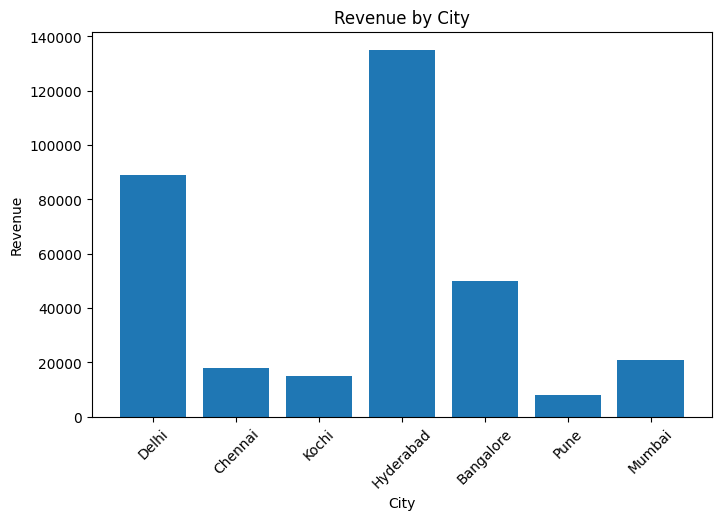

In [0]:
# #38 Bar chart: Revenue by City
import matplotlib.pyplot as plt

city_revenue_pd=silver_orders_df.groupBy(
    "city"
).sum(
    "revenue"
).withColumnRenamed(
    "sum(revenue)",
    "total_revenue"
).toPandas()

plt.figure(
    figsize=(8,5)
)
plt.bar(
    city_revenue_pd["city"],
    city_revenue_pd["total_revenue"]
)
plt.title(
    "Revenue by City"
)
plt.xlabel(
    "City"
)
plt.ylabel(
    "Revenue"
)
plt.xticks(
    rotation=45
)
plt.show()

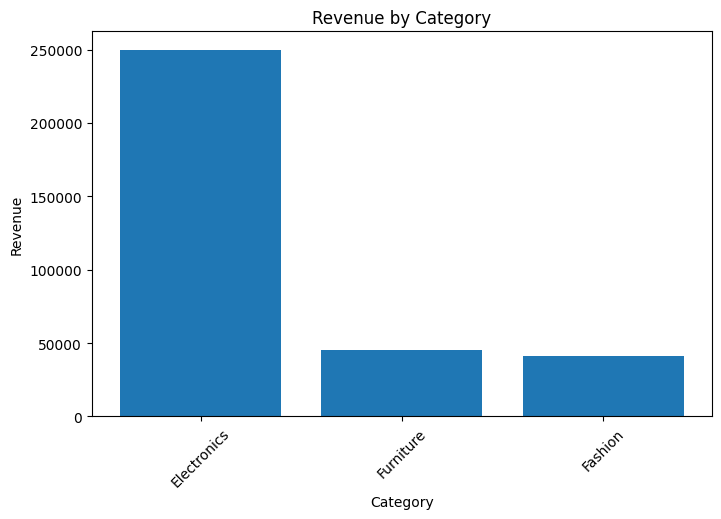

In [0]:
# #39 Bar chart: Revenue by Category
category_revenue_pd=silver_orders_df.groupBy(
    "category"
).sum(
    "revenue"
).withColumnRenamed(
    "sum(revenue)",
    "total_revenue"
).toPandas()

plt.figure(
    figsize=(8,5)
)
plt.bar(
    category_revenue_pd["category"],
    category_revenue_pd["total_revenue"]
)
plt.title(
    "Revenue by Category"
)
plt.xlabel(
    "Category"
)
plt.ylabel(
    "Revenue"
)
plt.xticks(
    rotation=45
)
plt.show()

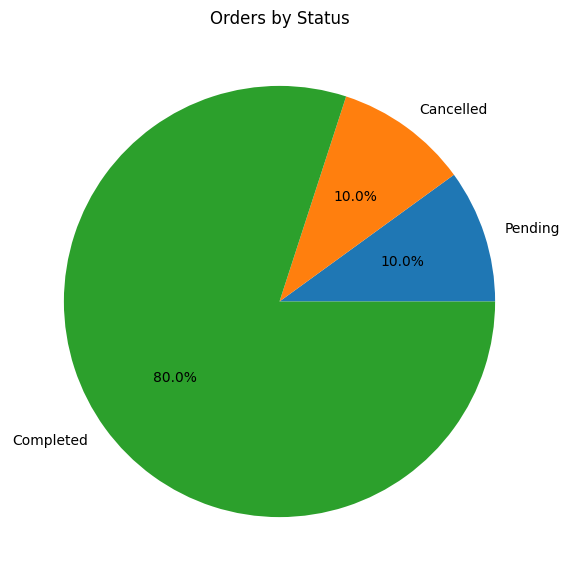

In [0]:
# #40 Pie chart: Orders by Status
status_pd=silver_orders_df.groupBy(
    "status"
).count().toPandas()

plt.figure(
    figsize=(7,7)
)
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title(
    "Orders by Status"
)
plt.show()

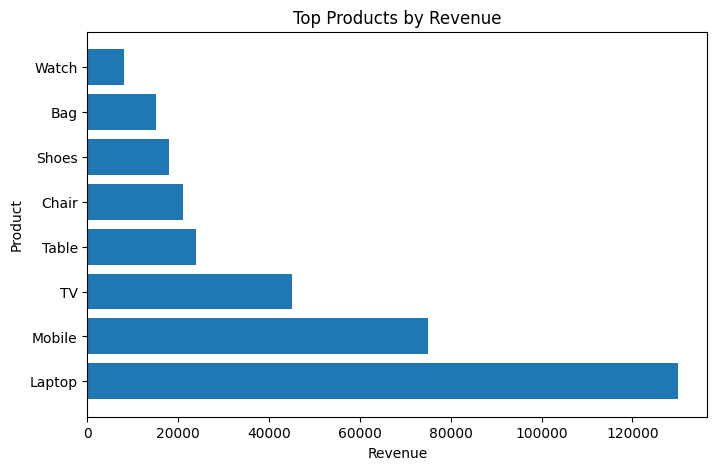

In [0]:
# #41 Horizontal bar chart: Top Products by Revenue
product_revenue_pd=silver_orders_df.groupBy(
    "product_name"
).sum(
    "revenue"
).withColumnRenamed(
    "sum(revenue)",
    "total_revenue"
).orderBy(
    col(
        "total_revenue"
    ).desc()
).toPandas()

plt.figure(
    figsize=(8,5)
)
plt.barh(
    product_revenue_pd["product_name"],
    product_revenue_pd["total_revenue"]
)
plt.title(
    "Top Products by Revenue"
)
plt.xlabel(
    "Revenue"
)
plt.ylabel(
    "Product"
)
plt.show()

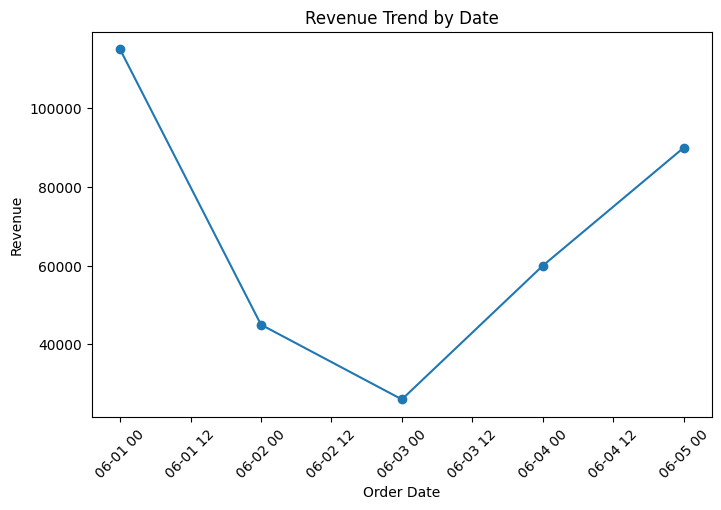

In [0]:
# #42 Line chart: Revenue Trend by Date
date_revenue_pd=silver_orders_df.groupBy(
    "order_date"
).sum(
    "revenue"
).withColumnRenamed(
    "sum(revenue)",
    "total_revenue"
).orderBy(
    "order_date"
).toPandas()

plt.figure(
    figsize=(8,5)
)
plt.plot(
    date_revenue_pd["order_date"],
    date_revenue_pd["total_revenue"],
    marker="o"
)
plt.title(
    "Revenue Trend by Date"
)
plt.xlabel(
    "Order Date"
)
plt.ylabel(
    "Revenue"
)
plt.xticks(
    rotation=45
)
plt.show()

In [0]:
# #43 Create managed table
silver_orders_df.write.format(
    "delta"
).mode(
    "overwrite"
).saveAsTable(
    "managed_retail_orders"
)

In [0]:
# #44 Create external table
silver_orders_df.write.format(
    "delta"
).mode(
    "overwrite"
).save(
    "/Volumes/ey_databricks/default/capstone/external_retail_orders"
)

# Unity Catalog requires a registered external location (cloud URI) for CREATE TABLE ... LOCATION.
# No external locations are registered in this workspace, so we read the Delta data
# written to the Volume path to verify external path-based access.
external_orders_df = spark.read.format("delta").load(
    "/Volumes/ey_databricks/default/capstone/external_retail_orders"
)
display(external_orders_df)

product_id,customer_id,order_id,order_date,quantity,status,customer_name,city,state,customer_type,product_name,category,unit_price,revenue,order_month,customer_segment
P101,C101,O1001,2026-06-01,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Laptop,Electronics,65000,65000,6,High Value
P102,C102,O1002,2026-06-01,2,Completed,Priya Reddy,Bangalore,Karnataka,Regular,Mobile,Electronics,25000,50000,6,Standard Value
P103,C103,O1003,2026-06-02,3,Pending,Amit Kumar,Mumbai,Maharashtra,Regular,Chair,Furniture,7000,21000,6,Standard Value
P104,C104,O1004,2026-06-02,2,Completed,Sneha Patel,Delhi,Delhi,Premium,Table,Furniture,12000,24000,6,High Value
P105,C105,O1005,2026-06-03,4,Cancelled,Farhan Ali,Chennai,Tamil Nadu,Regular,Shoes,Fashion,4500,18000,6,Standard Value
P106,C106,O1006,2026-06-03,1,Completed,Neha Singh,Pune,Maharashtra,Premium,Watch,Fashion,8000,8000,6,High Value
P107,C107,O1007,2026-06-04,1,Completed,Arjun Verma,Hyderabad,Telangana,Regular,TV,Electronics,45000,45000,6,Standard Value
P108,C108,O1008,2026-06-04,5,Completed,Meera Nair,Kochi,Kerala,Premium,Bag,Fashion,3000,15000,6,High Value
P102,C101,O1009,2026-06-05,1,Completed,Rahul Sharma,Hyderabad,Telangana,Premium,Mobile,Electronics,25000,25000,6,High Value
P101,C104,O1010,2026-06-05,1,Completed,Sneha Patel,Delhi,Delhi,Premium,Laptop,Electronics,65000,65000,6,High Value


In [0]:
# #45 Create temporary view
silver_orders_df.createOrReplaceTempView(
    "temp_retail_orders"
)

In [0]:
# #47 Compare scope and lifetime of each
print("Managed Table")
print("- Stored inside Databricks metastore")
print("- Data and metadata both managed by Databricks")
print("- If table is dropped, data is also removed")
print("- Can be accessed like a normal table name: managed_retail_orders")

print("\nExternal Table")
print("- Data is stored in external storage path")
print("- Metadata is in metastore, but data stays in storage")
print("- If table is dropped, underlying data usually remains")
print("- Can be accessed like a normal table name: external_retail_orders")

print("\nTemporary View")
print("- Scope is only current notebook/session")
print("- Not stored permanently")
print("- Disappears when session ends")
print("- Access using temp_retail_orders")

print("\nGlobal Temporary View")
print("- Scope is across notebooks in the same Spark application")
print("- Stored under global_temp database")
print("- Exists until cluster/session is active")
print("- Access using global_temp.global_retail_orders")

Managed Table
- Stored inside Databricks metastore
- Data and metadata both managed by Databricks
- If table is dropped, data is also removed
- Can be accessed like a normal table name: managed_retail_orders

External Table
- Data is stored in external storage path
- Metadata is in metastore, but data stays in storage
- If table is dropped, underlying data usually remains
- Can be accessed like a normal table name: external_retail_orders

Temporary View
- Scope is only current notebook/session
- Not stored permanently
- Disappears when session ends
- Access using temp_retail_orders

Global Temporary View
- Scope is across notebooks in the same Spark application
- Stored under global_temp database
- Exists until cluster/session is active
- Access using global_temp.global_retail_orders
